# Monte Carlo Options — Model Analysis

This notebook visualizes the complete pricing workflow.

We will look at:

1. Historical return statistics
2. GBM simulated price paths
3. Terminal stock-price distribution
4. Call payoff profile
5. Simulated payoff distribution
6. Monte Carlo convergence
7. Monte Carlo vs Black-Scholes
8. Volatility sensitivity
9. American put pricing with Longstaff-Schwartz

The notebook is intentionally separate from the core source files. The source files contain the reusable model logic; this notebook contains exploration and visualization.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Allow the notebook to import modules from ../src
ROOT = Path.cwd().resolve().parent
SRC = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from american_option import price_american_put_lsm
from black_scholes import black_scholes_call, black_scholes_put
from gbm import simulate_gbm_paths
from monte_carlo import price_european_option_mc
from returns import calculate_log_returns, calculate_statistics

print("Project root:", ROOT)


Project root: /Users/samarthuday/Github/monte-carlo-options


## 1. Model Inputs

For the pricing experiments we use:

- \(S_0=100\)
- \(K=110\)
- \(T=1\) year
- \(r=5\%\)
- \(\sigma=20\%\)

The historical-return example in `returns.py` is kept separate because the small five-price educational dataset is not a realistic volatility estimate.


In [2]:
S0 = 100.0
K = 110.0
T = 1.0
r = 0.05
sigma = 0.20

steps = 252
num_simulations = 10_000
seed = 42

print(f"S0 = ${S0:.2f}")
print(f"K = ${K:.2f}")
print(f"T = {T:.2f} years")
print(f"r = {r:.2%}")
print(f"sigma = {sigma:.2%}")


S0 = $100.00
K = $110.00
T = 1.00 years
r = 5.00%
sigma = 20.00%


## 2. Historical Returns

This reproduces the educational calculation in `src/returns.py`.


In [3]:
historical_prices = [100, 105, 103, 108, 106]

historical_returns = calculate_log_returns(historical_prices)
historical_stats = calculate_statistics(historical_returns)

print("Log returns:", historical_returns)
print("Mean return:", historical_stats["mean_return"])
print("Variance:", historical_stats["variance"])
print("Standard deviation:", historical_stats["standard_deviation"])
print("Annualized volatility:", historical_stats["annualized_volatility"])


Log returns: [0.04879016416943205, -0.019231361927887644, 0.0474022388945839, -0.01869213301215252]
Mean return: 0.014567227030993946
Variance: 0.001499292358851553
Standard deviation: 0.038720696776421176
Annualized volatility: 0.6146720055693048


## 3. Simulated GBM Price Paths

Each row is one simulated future.

Each column is one time point.

The first column is \(S_0\), and the final column is \(S_T\).


In [4]:
paths = simulate_gbm_paths(
    S0=S0,
    mu=r,
    sigma=sigma,
    T=T,
    steps=steps,
    num_simulations=num_simulations,
    seed=seed,
)

print("Path matrix shape:", paths.shape)
print("First 3 paths, first 5 time points:")
print(paths[:3, :5])


Path matrix shape: (10000, 253)
First 3 paths, first 5 time points:
[[100.         100.39659657 100.63179259  98.56299832  97.32658491]
 [100.          98.71004018  99.84645981 100.98589004 100.93761981]
 [100.         100.96198198  99.1183124   99.05766194  97.4031507 ]]


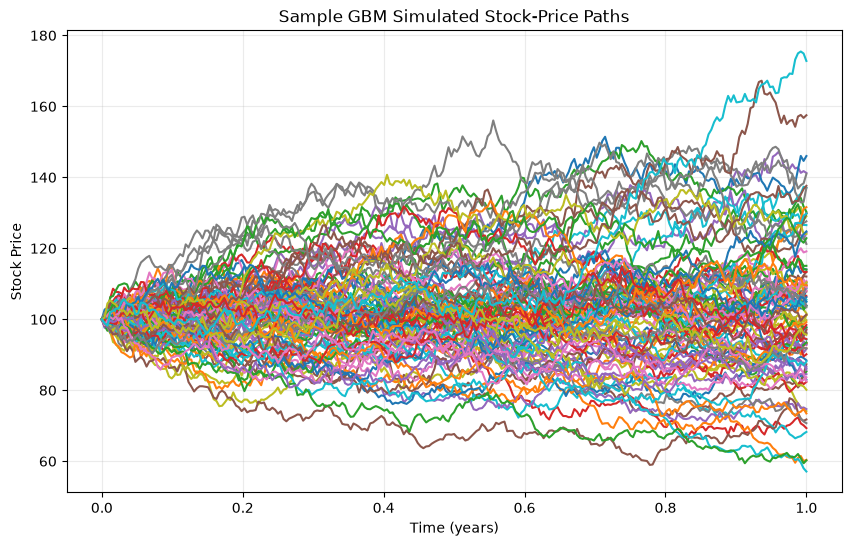

In [5]:
# Plot a sample of simulated paths.
time_grid = np.linspace(0, T, steps + 1)

plt.figure(figsize=(10, 6))

for i in range(100):
    plt.plot(time_grid, paths[i])

plt.title("Sample GBM Simulated Stock-Price Paths")
plt.xlabel("Time (years)")
plt.ylabel("Stock Price")
plt.grid(alpha=0.25)
plt.show()


### Interpretation

The paths all start at the same \(S_0\), but diverge because every path receives different random shocks.

We are not saying one of these paths will definitely happen.

They represent possible futures generated by the model.


## 4. Terminal Stock Prices

For a European option, the payoff depends on the terminal price \(S_T\).

The terminal prices are simply the last column of the path matrix.


In [6]:
terminal_prices = paths[:, -1]

print("Number of terminal prices:", len(terminal_prices))
print("First 10 terminal prices:", terminal_prices[:10])
print("Mean terminal price:", np.mean(terminal_prices))
print("Standard deviation:", np.std(terminal_prices))


Number of terminal prices: 10000
First 10 terminal prices: [103.83824018 109.42931953  85.2590532   93.24784114 141.23356013
  87.30540762  96.91976077  96.0370257  101.67463811 105.02414657]
Mean terminal price: 105.32489808900445
Standard deviation: 21.334578302275624


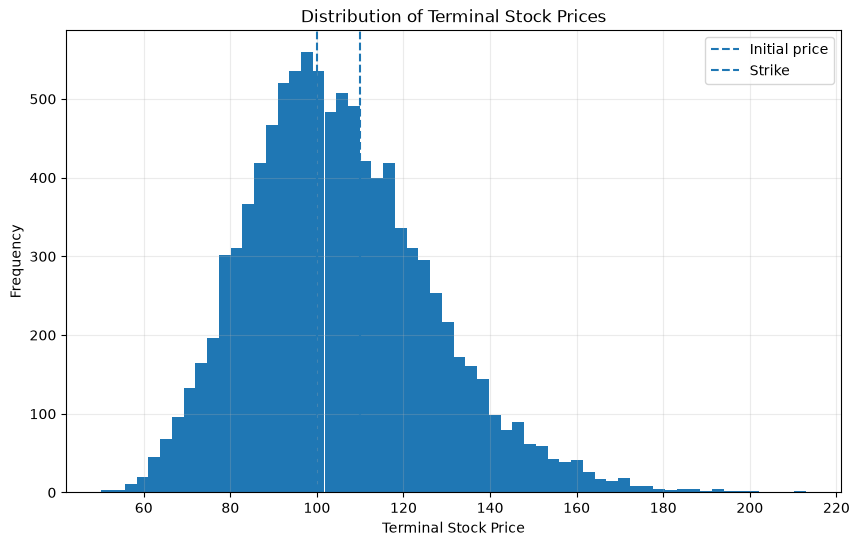

In [7]:
plt.figure(figsize=(10, 6))

plt.hist(terminal_prices, bins=60)

plt.axvline(S0, linestyle="--", label="Initial price")
plt.axvline(K, linestyle="--", label="Strike")

plt.title("Distribution of Terminal Stock Prices")
plt.xlabel("Terminal Stock Price")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 5. Call Payoff

For a European call:

\[
C_T=\max(S_T-K,0)
\]

Each terminal stock price produces one payoff.


In [8]:
payoffs = np.maximum(terminal_prices - K, 0.0)

print("First 10 terminal prices:", terminal_prices[:10])
print("First 10 call payoffs:", payoffs[:10])
print("Average payoff:", np.mean(payoffs))


First 10 terminal prices: [103.83824018 109.42931953  85.2590532   93.24784114 141.23356013
  87.30540762  96.91976077  96.0370257  101.67463811 105.02414657]
First 10 call payoffs: [ 0.          0.          0.          0.         31.23356013  0.
  0.          0.          0.          0.        ]
Average payoff: 6.47853996886495


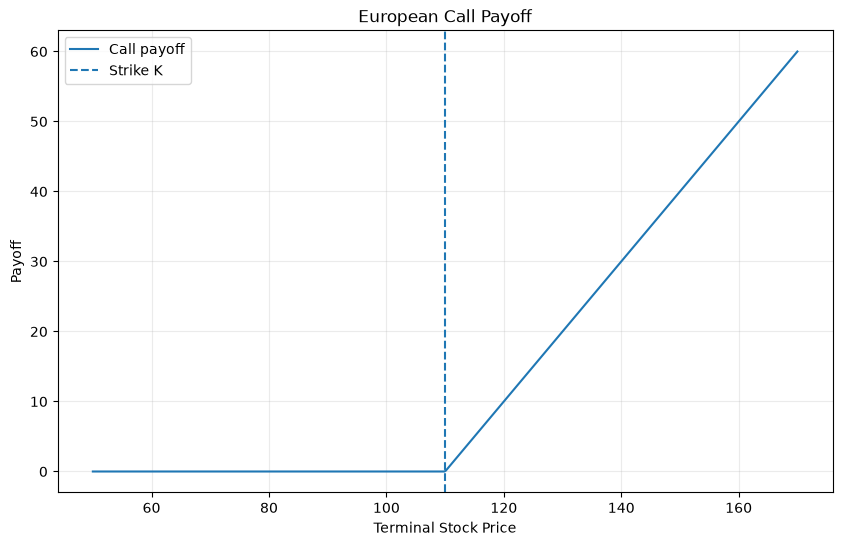

In [9]:
# Theoretical payoff profile as a function of ST.
stock_grid = np.linspace(50, 170, 500)
payoff_grid = np.maximum(stock_grid - K, 0)

plt.figure(figsize=(10, 6))
plt.plot(stock_grid, payoff_grid, label="Call payoff")
plt.axvline(K, linestyle="--", label="Strike K")
plt.title("European Call Payoff")
plt.xlabel("Terminal Stock Price")
plt.ylabel("Payoff")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


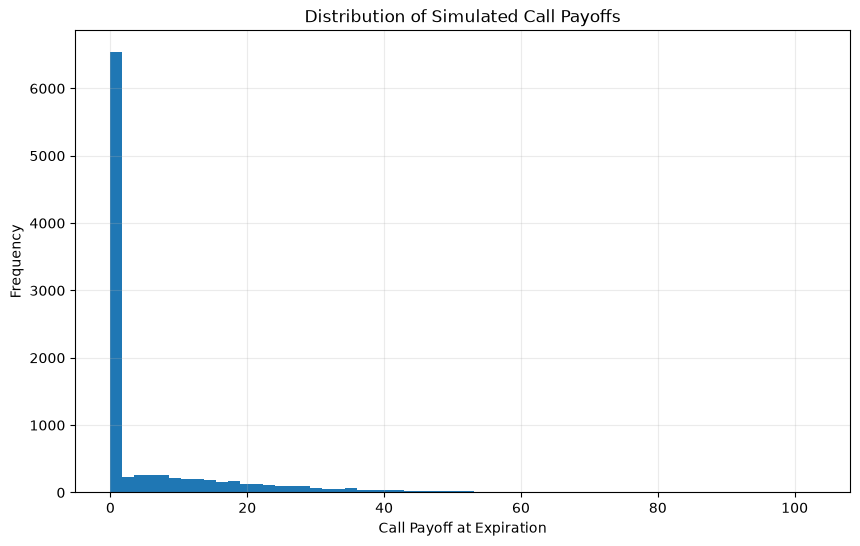

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(payoffs, bins=60)

plt.title("Distribution of Simulated Call Payoffs")
plt.xlabel("Call Payoff at Expiration")
plt.ylabel("Frequency")
plt.grid(alpha=0.25)
plt.show()


## 6. Monte Carlo European Call Price

The Monte Carlo estimator is:

\[
C_0
pprox
e^{-rT}

rac{1}{N}
\sum_{i=1}^{N}
\max(S_T^{(i)}-K,0)
\]

The important change from the earlier GBM learning exercise is that the stock is simulated under the **risk-neutral drift \(r\)** rather than the historical expected return \(\mu\).


In [11]:
mc_result = price_european_option_mc(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    steps=steps,
    num_simulations=num_simulations,
    option_type="call",
    seed=seed,
)

mc_price = mc_result["price"]

print(f"Monte Carlo call price: ${mc_price:.4f}")
print(f"Expected payoff: ${mc_result['expected_payoff']:.4f}")
print(f"Standard error: ${mc_result['standard_error']:.6f}")
print(
    "95% confidence interval: "
    f"(${mc_result['confidence_interval'][0]:.4f}, "
    f"${mc_result['confidence_interval'][1]:.4f})"
)


Monte Carlo call price: $6.1626
Expected payoff: $6.4785
Standard error: $0.117322
95% confidence interval: ($5.9326, $6.3925)


## 7. Black-Scholes Validation

For a European call, Black-Scholes gives an analytical benchmark.

We expect the Monte Carlo result to be close to Black-Scholes, with the difference explained partly by Monte Carlo sampling error.


In [12]:
bs_price = black_scholes_call(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
)

difference = mc_price - bs_price

comparison = pd.DataFrame({
    "Model": ["Monte Carlo", "Black-Scholes"],
    "Price": [mc_price, bs_price],
})

print(comparison)
print(f"Monte Carlo - Black-Scholes: ${difference:.6f}")


           Model     Price
0    Monte Carlo  6.162578
1  Black-Scholes  6.040088
Monte Carlo - Black-Scholes: $0.122490


## 8. Monte Carlo Convergence

Monte Carlo error decreases approximately as:

\[
SE\propto
rac{1}{\sqrt{N}}
\]

Therefore, increasing the number of simulations should generally make the estimate more stable.


In [13]:
simulation_counts = [
    1_000,
    2_500,
    5_000,
    10_000,
    25_000,
    50_000,
    100_000,
]

convergence_prices = []
convergence_se = []

for n in simulation_counts:
    result = price_european_option_mc(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigma=sigma,
        steps=steps,
        num_simulations=n,
        option_type="call",
        seed=42,
    )

    convergence_prices.append(result["price"])
    convergence_se.append(result["standard_error"])

convergence = pd.DataFrame({
    "Simulations": simulation_counts,
    "MC Price": convergence_prices,
    "Standard Error": convergence_se,
})

convergence


,Simulations,MC Price,Standard Error
0,1000,6.320408,0.389377
1,2500,6.052659,0.238752
2,5000,6.320332,0.169531
3,10000,6.162578,0.117322
4,25000,6.217383,0.074645
5,50000,6.070019,0.052391
6,100000,6.074742,0.037183


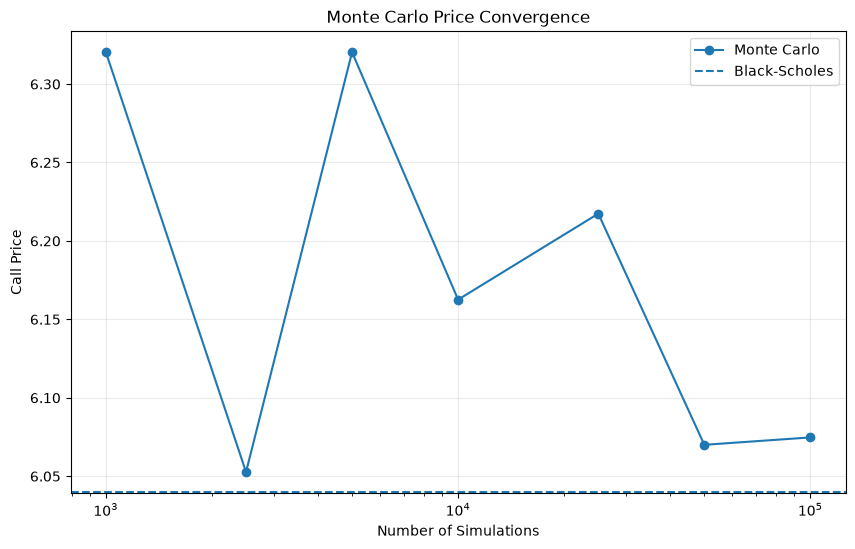

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    convergence["Simulations"],
    convergence["MC Price"],
    marker="o",
    label="Monte Carlo"
)

plt.axhline(
    bs_price,
    linestyle="--",
    label="Black-Scholes"
)

plt.xscale("log")

plt.title("Monte Carlo Price Convergence")
plt.xlabel("Number of Simulations")
plt.ylabel("Call Price")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


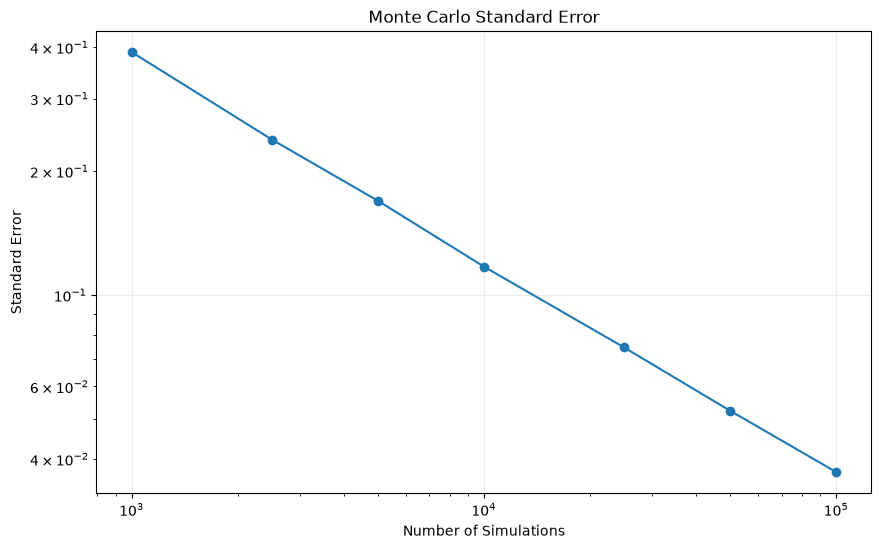

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    convergence["Simulations"],
    convergence["Standard Error"],
    marker="o"
)

plt.xscale("log")
plt.yscale("log")

plt.title("Monte Carlo Standard Error")
plt.xlabel("Number of Simulations")
plt.ylabel("Standard Error")
plt.grid(alpha=0.25)
plt.show()


## 9. Volatility Sensitivity

Option values generally increase with volatility because a call benefits from large upward outcomes while its downside payoff is floored at zero.


In [16]:
volatilities = np.array([0.10, 0.15, 0.20, 0.25, 0.30, 0.35])

mc_vol_prices = []
bs_vol_prices = []

for vol in volatilities:
    mc = price_european_option_mc(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigma=vol,
        steps=steps,
        num_simulations=50_000,
        option_type="call",
        seed=42,
    )

    mc_vol_prices.append(mc["price"])
    bs_vol_prices.append(
        black_scholes_call(S0, K, T, r, vol)
    )

volatility_table = pd.DataFrame({
    "Volatility": volatilities,
    "Monte Carlo": mc_vol_prices,
    "Black-Scholes": bs_vol_prices,
})

volatility_table


,Volatility,Monte Carlo,Black-Scholes
0,0.10,2.187717,2.173945
1,0.15,4.097359,4.075866
2,0.20,6.070019,6.040088
3,0.25,8.066464,8.026385
4,0.30,10.071977,10.020078
5,0.35,12.079651,12.014090


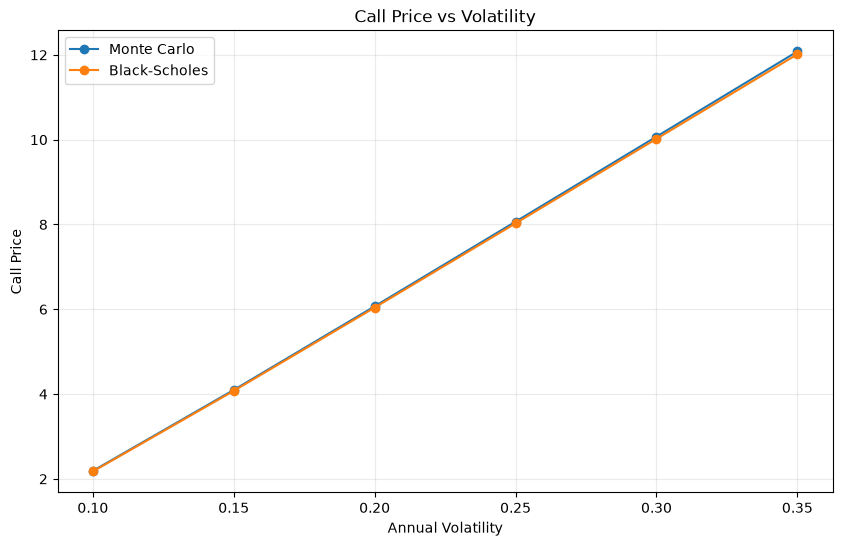

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    volatility_table["Volatility"],
    volatility_table["Monte Carlo"],
    marker="o",
    label="Monte Carlo"
)

plt.plot(
    volatility_table["Volatility"],
    volatility_table["Black-Scholes"],
    marker="o",
    label="Black-Scholes"
)

plt.title("Call Price vs Volatility")
plt.xlabel("Annual Volatility")
plt.ylabel("Call Price")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 10. American Put — Longstaff-Schwartz

American options require an exercise decision before expiration.

We demonstrate this with an American put.

The algorithm works backwards through the simulated paths and compares:

\[
	ext{Immediate Exercise Value}
\]

against:

\[
	ext{Estimated Continuation Value}
\]

The current implementation uses a quadratic regression basis:

\[
1,\ S,\ S^2
\]


In [18]:
american_S0 = 100.0
american_K = 100.0
american_T = 1.0
american_r = 0.05
american_sigma = 0.20

american_price, american_paths, american_cashflows = (
    price_american_put_lsm(
        S0=american_S0,
        K=american_K,
        T=american_T,
        r=american_r,
        sigma=american_sigma,
        steps=50,
        num_simulations=50_000,
        seed=42,
    )
)

european_put = black_scholes_put(
    S0=american_S0,
    K=american_K,
    T=american_T,
    r=american_r,
    sigma=american_sigma,
)

print(f"American put (LSM): ${american_price:.4f}")
print(f"European put (Black-Scholes): ${european_put:.4f}")
print(
    "American premium over European: "
    f"${american_price - european_put:.4f}"
)


American put (LSM): $6.0402
European put (Black-Scholes): $5.5735
American premium over European: $0.4667


## 11. Final Interpretation

The complete workflow is now:

```text
Historical prices
        ↓
Returns and volatility
        ↓
GBM simulation
        ↓
Many possible stock-price paths
        ↓
Terminal stock prices
        ↓
Option payoffs
        ↓
Average payoff
        ↓
Risk-neutral discounting
        ↓
Monte Carlo European price
        ↓
Black-Scholes validation
        ↓
Convergence analysis
        ↓
American put
        ↓
Longstaff-Schwartz early exercise
```

The key idea is that Monte Carlo is not a single formula. It is a sequence:

\[
oxed{
	ext{Simulate}

ightarrow
	ext{Calculate Payoff}

ightarrow
	ext{Average}

ightarrow
	ext{Discount}
}
\]

For American options, the additional problem is:

\[
oxed{
	ext{Decide when to exercise}
}
\]

and Longstaff-Schwartz estimates the continuation value needed for that decision.
